## Package Imports and Notebook Setup

In [3]:
!pip3 install pyro-ppl

  Obtaining dependency information for pyro-ppl from https://files.pythonhosted.org/packages/ed/37/def183a2a2c8619d92649d62fe0622c4c6c62f60e4151e8fbaa409e7d5ab/pyro_ppl-1.9.1-py3-none-any.whl.metadata
  Obtaining dependency information for opt-einsum>=2.3.2 from https://files.pythonhosted.org/packages/23/cd/066e86230ae37ed0be70aae89aabf03ca8d9f39c8aea0dec8029455b5540/opt_einsum-3.4.0-py3-none-any.whl.metadata
  Obtaining dependency information for pyro-api>=0.1.1 from https://files.pythonhosted.org/packages/fc/81/957ae78e6398460a7230b0eb9b8f1cb954c5e913e868e48d89324c68cec7/pyro_api-0.1.2-py3-none-any.whl.metadata
  Obtaining dependency information for torch>=2.0 from https://files.pythonhosted.org/packages/3f/14/e105b8ef6d324e789c1589e95cb0ab63f3e07c2216d68b1178b7c21b7d2a/torch-2.2.2-cp311-none-macosx_10_9_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 7.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 7.6 MB/s eta 0:0

In [ ]:
# Standard library
import json  # For parsing JSON
import math
import os

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyro
import pyro.distributions as dist
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from pyro.infer import SVI, TraceMeanField_ELBO
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer  # For one-hot encoding
from tqdm import trange

# Movie Genre Multi-Class Classification
## Data Cleaning Functions 📊

This section addresses broad functions used to acquire, clean, and filter data within the movie genre data set: Kaggle's IMDB movie descriptions. These functions are also applicable to new data sets that retain the correct features of columns and header names.

**Load_Data** helps to load the csv files into a pandas data frame while retaining only pertinent columns (Movie Name, Genre, Description)

**Clean_Data_Set** removes any repeating descriptions that were in rows by counting unique descriptions and comparing to the threshold of allowed unique descriptions which was 1.

**Filter_and_adjust_genres** removes any genres that are not specified in the genre list. This helps to contain our data within 9 specific genres to prevent over specificity in downstream training processes, ideally, preventing hyper-unique genres.

In [187]:
def load_data(folder_path: str) -> pd.DataFrame:
    """
    Loads and concatenates CSV files from a specified folder, retaining only specific columns.

    Parameters
    ----------
    folder_path : str
        Path to the folder containing CSV files.

    Returns
    -------
    pd.DataFrame
        Combined DataFrame with selected columns from all CSV files.
    """
    # Columns to keep from each CSV file
    use_columns = ['movie_name', 'genre', 'description']

    # List all CSV files in the folder
    csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

    # Read each CSV file, selecting only the desired columns
    df_list = [
        pd.read_csv(os.path.join(folder_path, file), usecols=lambda col: col in use_columns)
        for file in csv_files
    ]

    # Combine all individual DataFrames into a single DataFrame
    combined_df = pd.concat(df_list, ignore_index=True)

    return combined_df


def clean_data_set(df: pd.DataFrame, threshold: int) -> pd.DataFrame:
    """
    Removes rows with plot descriptions that appear more than a specified number of times.

    Parameters
    ----------
    df : pd.DataFrame
        The original DataFrame containing a 'description' column.
    threshold : int
        Maximum number of times a description is allowed before being considered duplicate.

    Returns
    -------
    pd.DataFrame
        A cleaned DataFrame with frequent duplicate descriptions removed.
    """
    # Count the number of occurrences of each description
    desc_counts = df['description'].value_counts()

    # Identify descriptions that appear more than the threshold
    repeated_descriptions = desc_counts[desc_counts > threshold].index

    # Filter out rows with overly repeated descriptions
    df = df[~df['description'].isin(repeated_descriptions)]

    print("Removed descriptions that appeared more than once:")

    return df


def filter_and_adjust_genres(df: pd.DataFrame, allowed_genres: list) -> pd.DataFrame:
    """
    Filters a DataFrame to keep rows where at least one genre is in the allowed list,
    and updates each genre list to only include allowed genres.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing a 'genre' column with lists of genres per movie.
    allowed_genres : list
        A list of allowed genre strings.

    Returns
    -------
    pd.DataFrame
        Filtered DataFrame with adjusted genre lists containing only allowed genres.
    """
    # Convert allowed genres to a set for faster lookup
    allowed_genres_set = set(allowed_genres)

    new_genres_list = []  # Will hold updated genre lists for all rows
    rows_to_keep_mask = []  # Boolean mask to decide which rows to retain

    for genre_list in df['genre']:
        if isinstance(genre_list, list):
            # Keep only the genres that are in the allowed list
            valid_genres_in_row = [genre for genre in genre_list if genre in allowed_genres_set]

            if valid_genres_in_row:
                rows_to_keep_mask.append(True)
                new_genres_list.append(valid_genres_in_row)
            else:
                rows_to_keep_mask.append(False)
                new_genres_list.append([])
        else:
            # Non-list or malformed entries are dropped
            rows_to_keep_mask.append(False)
            new_genres_list.append([])

    # Filter the DataFrame using the boolean mask
    filtered_df = df[rows_to_keep_mask].copy()

    # Filter new genre lists accordingly and assign them back
    filtered_new_genres = [genres for keep, genres in zip(rows_to_keep_mask, new_genres_list) if keep]
    filtered_df['genre'] = filtered_new_genres

    return filtered_df

In [188]:
df = load_data('/Users/malcolmrenney/Downloads/MBML_main_data')

## Data Acquisition Exploration  📊

The exploration of preliminary movie data sets is important to understand any limitations that may skew the LDA model in a specific way or produce unexpected errors that are not easily seen. The movie directory is divided between movie_title, genre, and description and intial probing of the data unveiled several important requirements for pre-processing. 
* **Text Repitition and NaN Error** First, the data was analyzed for repeated values in the description because it was noticed that the data set was prone to repeated descriptions. To ensure that the model is not skewed by proliferation of words, the repeated descriptions were removed. The first test also prints results pertaining to missing NaN values found in the data. Its found that actually no empty strings were in the genre or description columns, however some movie titles contained NaN values. Since genre and descriptions are pertinant data to the model no values were removed based on NaN errors. Despite this, it was found that descriptions with no text were replaced with the phrase "Add to Plot" and extra phrases like "See full summery" were added onto dscriptions, so the frequency of more phrases were measured too.
* **Genre Count Analysis** Second, the data contained movies with multiple genres and had more genres than the genre_list the LDA model is constrained to. As seen in the bar chart, all genres are accounted for and in the data cleaning, genres not in the pre-determined list were removed.
* **Word Frequency Analysis** Third, the data was scanned for word frequency in the movie descriptions. After looping through all descriptions, ultra common words like "a", "the", "to", "of", and "and" take a large percentage of overviews. Therefore, in the data vectorization and thinning section, the data is limited by english stop_words, to prevent any skewed hallucinations to common words in the model training stage.

In [190]:
# finds and print two sample rows with repeated descriptions for prelim analysis
print("\nTwo sample rows with repeated descriptions:")
desc_counts = df['description'].value_counts()
repeated_descriptions = desc_counts[desc_counts > 1].index
if not repeated_descriptions.empty:
    repeated_df = df[df['description'].isin(repeated_descriptions)]
    samples = repeated_df.head(2) if len(repeated_df) >= 2 else repeated_df
    for idx, row in samples.iterrows():
        print(f"\nRow {idx}:")
        print(f"Movie Name: {row['movie_name']}")
        print(f"Genre: {row['genre']}")
        for i in range(1, desc_counts[row['description']] + 1):
            print(f"Description {i}: {row['description']}")
        print(f"Description Count: {desc_counts[row['description']]}")
else:
    print("No repeated descriptions found in the dataset.")

# finds and prints two sample rows with NaN values if available in ONLY 'genre' or 'description' b/c these are the only important values for data
print("\nTwo sample rows with NaN values in genre or description:")
nan_rows = df[df[['genre', 'description']].isna().any(axis=1)]
if not nan_rows.empty:
    nan_samples = nan_rows.head(2) if len(nan_rows) >= 2 else nan_rows
    for idx, row in nan_samples.iterrows():
        print(f"\nRow {idx}:")
        print(f"Movie Name: {row['movie_name']}")
        print(f"Genre: {row['genre']}")
        print(f"Description: {row['description']}")
else:
    print("No rows with NaN values in genre or description found in the dataset.")

# finds columns with description replaces by the phrase Add to Plot
print("\nFrequency of 'Add a Plot' in description column:")
frequency = df['description'].astype(str).str.strip().eq('Add a Plot').sum()
total_rows = len(df)
print(f"{frequency} out of {total_rows} rows")
print(f"Percentage: {(frequency / total_rows * 100):.2f}%")

print("\nFrequency of 'See full Summary' in 'description' column:")
frequency = df['description'].astype(str).str.lower().str.contains('see full summary', case=False, na=False).sum()
total_rows = len(df)
print(f"{frequency} out of {total_rows} rows")
print(f"Percentage: {(frequency / total_rows * 100):.2f}%")


Two sample rows with repeated descriptions:

Row 0:
Movie Name: Fast X
Genre: Action, Crime, Mystery
Description 1: Dom Toretto and his family are targeted by the vengeful son of drug kingpin Hernan Reyes.
Description 2: Dom Toretto and his family are targeted by the vengeful son of drug kingpin Hernan Reyes.
Description 3: Dom Toretto and his family are targeted by the vengeful son of drug kingpin Hernan Reyes.
Description 4: Dom Toretto and his family are targeted by the vengeful son of drug kingpin Hernan Reyes.
Description Count: 4

Row 1:
Movie Name: Glass Onion
Genre: Comedy, Crime, Drama
Description 1: Famed Southern detective Benoit Blanc travels to Greece for his latest case.
Description 2: Famed Southern detective Benoit Blanc travels to Greece for his latest case.
Description 3: Famed Southern detective Benoit Blanc travels to Greece for his latest case.
Description Count: 3

Two sample rows with NaN values in genre or description:
No rows with NaN values in genre or descri


Debugging: Genre column types and sample values:
DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350606 entries, 0 to 350605
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   movie_name   350602 non-null  object
 1   genre        350606 non-null  object
 2   description  350606 non-null  object
dtypes: object(3)
memory usage: 8.0+ MB
None

Sample of genre column (first 5 rows):
['Action, Crime, Mystery', 'Comedy, Crime, Drama', 'Crime, Horror, Mystery', 'Crime, Horror, Mystery', 'Crime, Drama, Thriller']

Unique types in genre column:
genre
<class 'str'>    350606
Name: count, dtype: int64

Counting distinct genres and bar chart:

Distinct genre counts:
Action: 102937
Adult: 7
Adventure: 58454
Animation: 10630
Biography: 5499
Comedy: 62508
Crime: 69859
Drama: 131218
Family: 24602
Fantasy: 30430
Film-Noir: 1671
Game-Show: 8
History: 13549
Horror: 60472
Music: 4507
Musical: 4870
Mystery: 36177
News:

/var/folders/t5/2l7s67k562z49zwbts2l33sr0000gn/T/ipykernel_15330/2432557872.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=genres, palette='husl')


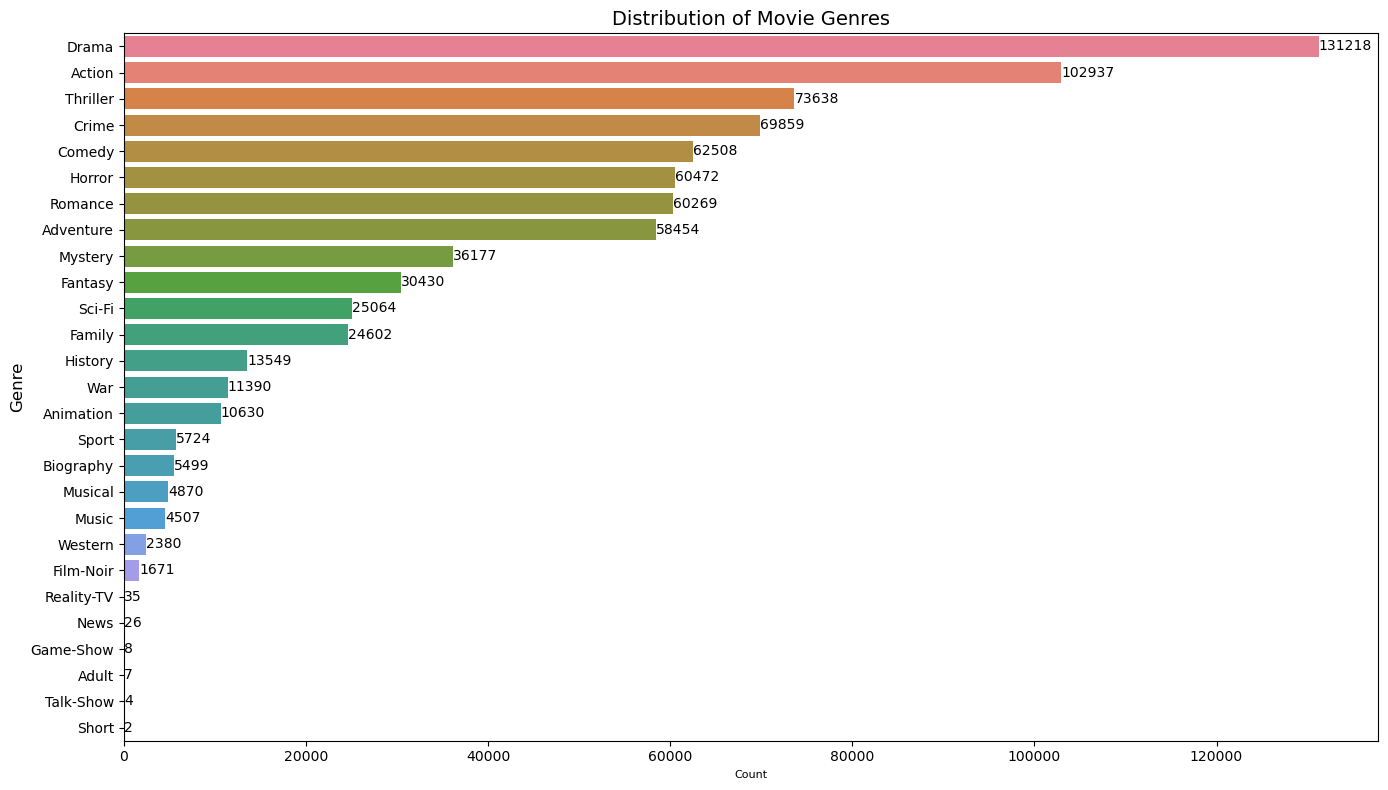

In [191]:
print("\nDebugging: Genre column types and sample values:")
print("DataFrame Info:")
print(df.info())
print("\nSample of genre column (first 5 rows):")
print(df['genre'].head().to_list())
print("\nUnique types in genre column:")
print(df['genre'].apply(type).value_counts())
print("\nCounting distinct genres and bar chart:")

# initializes the dictionary to count genres
genre_counts = {}
# this loops through the genre column and reads only text genres present
for genres in df['genre']:
    if pd.isna(genres):  # no NaN values
        continue
    # handle different types
    if isinstance(genres, str):
        # split string genres and strip whitespace
        genre_list = [genre.strip() for genre in genres.split(',') if genre.strip()]
    elif isinstance(genres, list):
        # sse list directly, strip strings if needed
        genre_list = [genre.strip() if isinstance(genre, str) else genre for genre in genres if genre]
    else:
        # Skip invalid types
        continue
    # count each genre in the directory
    for genre in genre_list:
        if genre: 
            genre_counts[genre] = genre_counts.get(genre, 0) + 1
# numbered genre counts in entire directory
print("\nDistinct genre counts:")
for genre, count in sorted(genre_counts.items()):
    print(f"{genre}: {count}")

# bar chart of the all the genres in the preliminary data set
if genre_counts:
    plt.figure(figsize=(14, 8))
    sorted_genres = sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)
    genres, counts = zip(*sorted_genres) if sorted_genres else ([], [])
    sns.barplot(x=counts, y=genres, palette='husl')
    plt.xlabel('Count', fontsize=8)
    plt.ylabel('Genre', fontsize=12)
    plt.title('Distribution of Movie Genres', fontsize=14)
    for i, count in enumerate(counts):
        plt.text(count + 0.5, i, str(count), va='center', fontsize=10)
    plt.tight_layout()
    #plt.savefig('/Users/malcolmrenney/Downloads/genres_bar_chart.png', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("No genres found")


In [192]:
from collections import Counter
import re

print("Analyzing word frequency in descriptions")
# Initialize a counter for words
word_counts = Counter()

# total word count for percentage calculation
total_words = 0

# this loops through the descriptions
for desc in df['description']:
    if pd.isna(desc):  # Skip NaN values
        continue
    # clean, tokenize, and convert to lowercase and remove punctuation
    words = re.findall(r'\b\w+\b', str(desc).lower())
    word_counts.update(words)
    total_words += len(words)

# top 20 most common words
top_words = word_counts.most_common(20)

# data word allocation in array
matrix = []
for word, count in top_words:
    percentage = (count / total_words * 100) if total_words > 0 else 0
    matrix.append([word, count, f"{percentage:.2f}%"])

# this is a matrix table of the most common words
print("\nTop 20 most common words in descriptions:")
print(f"{'Word':<20} {'Count':<10} {'Percentage':<10}")
print("-" * 40)
for row in matrix:
    print(f"{row[0]:<20} {row[1]:<10} {row[2]:<10}")

Analyzing word frequency in descriptions

Top 20 most common words in descriptions:
Word                 Count      Percentage
----------------------------------------
a                    511409     6.04%     
the                  405108     4.79%     
to                   243483     2.88%     
of                   232675     2.75%     
and                  208140     2.46%     
in                   168610     1.99%     
is                   122397     1.45%     
his                  117557     1.39%     
see                  74006      0.87%     
an                   73914      0.87%     
full                 73673      0.87%     
with                 73113      0.86%     
her                  71813      0.85%     
summary              70848      0.84%     
plot                 69478      0.82%     
s                    67331      0.80%     
add                  64632      0.76%     
he                   63103      0.75%     
on                   58136      0.69%     
for            

## Data Acquisition Cleaning 📊

This section loads the required data set and applies cleaning functions to identify missing values (NaN) and unconventional genres to prepare data for vectorization. The predefined genre list that the LDA classifier will test is constrained to the **genre_list** and many movie descriptions are removed as seen the the previous bar chart. Once the movies are filtered and genre adjusted, it is compared with uncleaned data. As a result, roughly 75% of the data is intact which allows for enough training and testing data for the model.

In [193]:
# Clean the dataset by dropping entries with missing values
movies_prior_to_cleaning = df.shape[0]
df.dropna(subset=['description', 'movie_name', 'genre'], inplace=True)
df = clean_data_set(df, 1)

# Define established genres
#genre_list = ['Action', 'Adventure','Crime', 'Family', 'Fantasy',
#       'History', 'Horror', 'Mystery', 'Romance', 'Sci-Fi', 'Sport',
#       'Thriller', 'War']

genre_list = ['Action', 'Adventure', 'Fantasy', 'Horror', 'Romance', 'Sci-Fi', 'Sport','Thriller', 'War']

# Convert genre format
df['genre'] = df['genre'].apply(lambda x: [genre.strip() for genre in x.split(',')])

# Remove all rows that does not have these genres.
df = filter_and_adjust_genres(df, genre_list)

movies_after_cleaning = df.shape[0]
df.reset_index(drop=True, inplace=True)
print(f"Has removed {movies_prior_to_cleaning-movies_after_cleaning} movies from the dataset, corresponding to {((movies_prior_to_cleaning - movies_after_cleaning) / movies_prior_to_cleaning)*100:.2f}%")

Removed descriptions that appeared more than once:
Has removed 262183 movies from the dataset, corresponding to 74.78%


## Data Vectorization and Thinning 📊

Following preliminary data exploration and to prepare neural network training, an indexed "bag-of-words" is created to change the text movie descriptions into numerical components. 
* **CountVectorizer** The vectorizer intializes a vocabulary structure of 15000 words and filters out overly common words such as "the" and "and" and removes words appearing in 80% of documents and ultra rare words found in very few documents.
* **docs** Converts the bag-of-words into a data frame and tranforms the word matrix into a tensor for the neural network.
* **vocab** Builds the dictionary of vectorized words and their document index with the previous functional components.
* **One_hot** Converts categorical genre data into binary vectored data  where single numerical values represent each genre. This will help for training and genre prediction in downstream processing.

In [196]:
# Create the index
vectorizer = CountVectorizer(max_df=0.8, min_df=2, max_features= 15000, stop_words='english')
docs = torch.from_numpy(vectorizer.fit_transform(df['description']).toarray())

# Create the vocabulary
vocab = pd.DataFrame(columns=['word', 'index'])
vocab['word'] = vectorizer.get_feature_names_out()
vocab['index'] = vocab.index
print('Dictionary size: %d' % len(vocab))
print('Corpus size: {}'.format(docs.shape))

# One-hot encode the genres
mlb = MultiLabelBinarizer()
genre_onehot = pd.DataFrame(mlb.fit_transform(df['genre']), columns=mlb.classes_, index=df.index)
genre_names = genre_onehot.columns
genre_values = genre_onehot.values
genre = df['genre'].values

Dictionary size: 15000
Corpus size: torch.Size([88423, 15000])


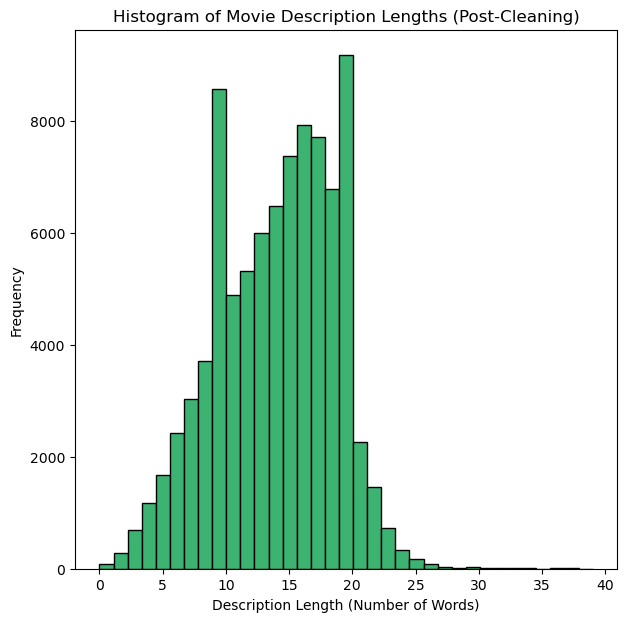

In [197]:
description_lengths = torch.sum(docs, axis=1)  # Sum of word counts per description

# histogram of description lengths
plt.figure(figsize=(7, 7))
plt.hist(description_lengths, bins=35, color='mediumseagreen', edgecolor='black')
plt.title('Histogram of Movie Description Lengths (Post-Cleaning)')
plt.xlabel('Description Length (Number of Words)')
plt.ylabel('Frequency')
plt.show()

## Test and Training Data Splitting 📊

This code intiailizes upstream aspects of the machine learning pipeline. The LDA classifier will be trained on 80% of the data while the remaining 20% is retained for testing and tuning the model's hyperparameters.

* **Train_test_split** accounts for 3 categories of data: (1) training/testing set of vectorized movie descriptions, (2) training/testing set of one-hot encoded genres, and (3) indexed rows of the data frames.
* **float32** addresses the underlying data types of Pytorch ensuring smooth computational load when training and testing.

In [198]:
train_docs, test_docs, train_genre, test_genre, train_index, test_index = train_test_split(docs, genre_values, df.index, test_size=0.2, random_state=42, shuffle=True)
# convert to float32
train_docs = train_docs.to(torch.float32).to(device)
test_docs = test_docs.to(torch.float32).to(device)
train_genre = torch.from_numpy(train_genre).to(torch.float32).to(device)
test_genre = torch.from_numpy(test_genre).to(torch.float32)

NameError: name 'device' is not defined